In [1]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Load the combined dataset
df = pd.read_csv('all_data.csv')

# 1. FIX: Standardize column names to remove trailing spaces
df.columns = df.columns.str.strip()

# 2. FIX: Consolidate Web Attack variants (using lowercase 'label' as per your load)
# Using a 'contains' search is safer against weird encoding symbols
df.loc[df['label'].str.contains('Web Attack', case=False, na=False), 'label'] = 'Web Attack'

# Define feature columns
feature_columns = [
    "Bwd Packet Length Std", "Destination Port", "Fwd Packet Length Std", 
    "Fwd Packet Length Max", "Flow IAT Min", "Flow IAT Mean", "Bwd Packet Length Mean"
]

# Filter to use only the selected columns and the target column "label"
df = df[feature_columns + ["label"]]

# 3. FIX: Multi-class label encoding (Ensuring we use 'Label' with capital L for the new column)
df['Label'], label_mapping = pd.factorize(df['label'])

# Display the label mapping for reference
print("Label Mapping:", dict(enumerate(label_mapping)))

# Separate features and target
X = df[feature_columns]  

# 4. FIX: Force y to be an integer array to avoid "Unknown label type" error
y = df['Label'].astype(int)  

# 5. FIX: Add stratify=y to ensure all attack classes are represented in the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Random Forest model
model = RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1)
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()

# Predict and evaluate the model on the test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print("\nModel Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Training Time: {end_time - start_time:.4f} seconds")

# Save the trained model
joblib.dump(model, 'attack_detection_model.pkl')
print("\nModel saved as 'attack_detection_model.pkl'")

Label Mapping: {0: 'BENIGN', 1: 'FTP-Patator', 2: 'SSH-Patator', 3: 'DoS slowloris', 4: 'DoS Slowhttptest', 5: 'DoS Hulk', 6: 'DoS GoldenEye', 7: 'Heartbleed', 8: 'Web Attack', 9: 'Infiltration', 10: 'Bot', 11: 'PortScan', 12: 'DDoS'}

Model Evaluation:
Accuracy: 0.8866
Precision: 0.3729
Recall: 0.1892
F1-Score: 0.2145
Training Time: 4.8405 seconds

Model saved as 'attack_detection_model.pkl'


/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [2]:
# 1. Use a real slice of your test data to see if it predicts correctly
# This takes the first 5 rows from your X_test
new_data = X_test.head(5) 

# 2. Predict using the loaded model
predicted_labels = model.predict(new_data)

# 3. Map back to names (using the mapping we printed earlier)
predicted_attack_types = [label_mapping[label] for label in predicted_labels]

print("Input Data Features:\n", new_data)
print("\nPredicted Attack Names:", predicted_attack_types)


Input Data Features:
          Bwd Packet Length Std  Destination Port  Fwd Packet Length Std  \
2567063               0.000000               443               0.000000   
1140941            4065.734263                80             135.325410   
1700022               0.000000                53               0.000000   
753440                0.000000                53               0.000000   
2324852             657.675126               443              66.898347   

         Fwd Packet Length Max  Flow IAT Min  Flow IAT Mean  \
2567063                      6             3   3.000000e+00   
1140941                    335             6   8.835863e+06   
1700022                     27             1   1.175333e+04   
753440                      46           544   5.440000e+02   
2324852                    188            10   3.687968e+05   

         Bwd Packet Length Mean  
2567063                0.000000  
1140941             1932.500000  
1700022               88.000000  
753440      

In [3]:
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load the saved model
model = joblib.load('attack_detection_model.pkl')

# Define the feature columns used during training
feature_columns = [
    "Bwd Packet Length Std", "Destination Port", "Fwd Packet Length Std", 
    "Fwd Packet Length Max", "Flow IAT Min", "Flow IAT Mean", "Bwd Packet Length Mean"
]

# 2. FIXED: Reversed mapping logic to handle CSV strings to numeric prediction
# Ensure this matches the names used in your 'all_data.csv'
label_mapping = {
    0: "BENIGN", 1: "Bot", 2: "DDoS", 3: "DoS GoldenEye", 
    4: "DoS Hulk", 5: "DoS Slowhttptest", 6: "DoS slowloris", 
    7: "FTP-Patator", 8: "Heartbleed", 9: "Infiltration", 
    10: "PortScan", 11: "SSH-Patator", 12: "Web Attack"
}
reverse_mapping = {v: k for k, v in label_mapping.items()}

# 3. Load the specific attack file
df_bot = pd.read_csv('./attacks/DoS Hulk.csv')

# 4. FIX: Strip column names to avoid "KeyError: 'label'"
df_bot.columns = df_bot.columns.str.strip()

# 5. FIX: Consolidate Web Attack naming in the validation file
df_bot.loc[df_bot['label'].str.contains('Web Attack', case=False, na=False), 'label'] = 'Web Attack'

# Select features and handle NaNs
X_bot = df_bot[feature_columns].fillna(0)

# 6. FIX: Map labels safely (if name doesn't exist, it marks as -1 to flag error)
y_true = df_bot['label'].map(reverse_mapping).fillna(-1).astype(int)

# 7. Predict
predicted_labels = model.predict(X_bot)

# 8. Calculate and Print Metrics
accuracy = accuracy_score(y_true, predicted_labels)
precision = precision_score(y_true, predicted_labels, average='macro', zero_division=0)
recall = recall_score(y_true, predicted_labels, average='macro', zero_division=0)
f1 = f1_score(y_true, predicted_labels, average='macro', zero_division=0)

print(f"--- Results for {df_bot['label'].iloc[0]} ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nSample Predictions:", [label_mapping[label] for label in predicted_labels[:10]])

--- Results for BENIGN ---
Accuracy: 0.7110
F1-Score: 0.2342

Sample Predictions: ['BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN']


In [4]:
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load the saved model
model = joblib.load('attack_detection_model.pkl')

# Define the feature columns used during training
feature_columns = [
    "Bwd Packet Length Std", "Destination Port", "Fwd Packet Length Std", 
    "Fwd Packet Length Max", "Flow IAT Min", "Flow IAT Mean", "Bwd Packet Length Mean"
]

# Label mapping
label_mapping = {
    0: "BENIGN", 1: "Bot", 2: "DDoS", 3: "DoS GoldenEye", 
    4: "DoS Hulk", 5: "DoS Slowhttptest", 6: "DoS slowloris", 
    7: "FTP-Patator", 8: "Heartbleed", 9: "Infiltration", 
    10: "PortScan", 11: "SSH-Patator", 12: "Web Attack"
}
reverse_mapping = {v: k for k, v in label_mapping.items()}

# 2. Load the specific DDoS dataset
df_ddos = pd.read_csv('./attacks/DDoS.csv')

# 3. FIX: Clean columns and handle label encoding
df_ddos.columns = df_ddos.columns.str.strip()
df_ddos.loc[df_ddos['label'].str.contains('Web Attack', case=False, na=False), 'label'] = 'Web Attack'

# Select features and handle NaNs
X_ddos = df_ddos[feature_columns].fillna(0)

# 4. FIX: Map labels safely
y_true = df_ddos['label'].map(reverse_mapping).fillna(-1).astype(int)

# 5. Predict
predicted_labels = model.predict(X_ddos)

# 6. Calculate Metrics (using 'weighted' average is better for single-attack files)
accuracy = accuracy_score(y_true, predicted_labels)
f1 = f1_score(y_true, predicted_labels, average='weighted', zero_division=0)

print(f"--- Results for DDoS Validation ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nSample Predictions:", [label_mapping[label] for label in predicted_labels[:10]])

--- Results for DDoS Validation ---
Accuracy: 0.7173
F1-Score: 0.6691

Sample Predictions: ['BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN']


In [5]:
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load the saved model
model = joblib.load('attack_detection_model.pkl')

feature_columns = [
    "Bwd Packet Length Std", "Destination Port", "Fwd Packet Length Std", 
    "Fwd Packet Length Max", "Flow IAT Min", "Flow IAT Mean", "Bwd Packet Length Mean"
]

label_mapping = {
    0: "BENIGN", 1: "Bot", 2: "DDoS", 3: "DoS GoldenEye", 
    4: "DoS Hulk", 5: "DoS Slowhttptest", 6: "DoS slowloris", 
    7: "FTP-Patator", 8: "Heartbleed", 9: "Infiltration", 
    10: "PortScan", 11: "SSH-Patator", 12: "Web Attack"
}
reverse_mapping = {v: k for k, v in label_mapping.items()}

# 2. Load PortScan and STRIP columns
df_test = pd.read_csv('./attacks/PortScan.csv')
df_test.columns = df_test.columns.str.strip()

# 3. Consolidate labels for true values
df_test['label_clean'] = df_test['label'].replace({
    'Web Attack  Brute Force': 'Web Attack',
    'Web Attack  XSS': 'Web Attack',
    'Web Attack  Sql Injection': 'Web Attack'
})

# 4. Map to numeric safely
y_true = df_test['label_clean'].map(reverse_mapping).fillna(0).astype(int)
X_test = df_test[feature_columns].fillna(0)

# 5. Predict
predicted_labels = model.predict(X_test)

# 6. Metrics (Using 'weighted' to see real performance on this specific file)
accuracy = accuracy_score(y_true, predicted_labels)
f1 = f1_score(y_true, predicted_labels, average='weighted', zero_division=0)

print(f"--- Results for PortScan Validation ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nFirst 10 Predictions:", [label_mapping[label] for label in predicted_labels[:10]])

--- Results for PortScan Validation ---
Accuracy: 0.7038
F1-Score: 0.5815

First 10 Predictions: ['BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN', 'BENIGN']


# for combined features

# only by Random forest

In [7]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# 1. Load the data
df = pd.read_csv('all_data.csv')
df.columns = df.columns.str.strip() # Fixes hidden spaces

# 2. Consolidate Web Attack variants
df.loc[df['label'].str.contains('Web Attack', case=False, na=False), 'label'] = 'Web Attack'

# 3. Define the combined feature columns (Removed the duplicate 'Bwd Packet Length Mean')
combined_features = [
    "Destination Port", "Bwd Packet Length Mean", "Flow IAT Min", "Flow IAT Std", "Flow Duration",
    "Bwd Packet Length Std", "Total Backward Packets", "Total Length of Fwd Packets", "Fwd Packet Length Max",
    "Flow Packets/s", "Fwd Packet Length Min", "Bwd Packet Length Max", "Flow Bytes/s", "Fwd Packet Length Mean",
    "Flow IAT Mean", "Flow IAT Max", "Total Fwd Packets"
]

# 4. Multi-class label encoding
df['Label_ID'], label_mapping_array = pd.factorize(df['label'])
label_mapping = dict(enumerate(label_mapping_array))

# 5. Prepare X and y
X = df[combined_features].fillna(0)
y = df['Label_ID'].astype(int) # Forces integer to avoid Scikit-Learn errors

# 6. Split with Stratification (Crucial for multi-class balance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. Train
model = RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1)
start_time = time.time()
model.fit(X_train, y_train)
end_time = time.time()

# 8. Evaluate
y_pred = model.predict(X_test)
print(f"Accuracy with Combined Features: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.4f}")

# 9. Save as a different name so you don't overwrite your first model
joblib.dump(model, 'combined_attack_model.pkl')
print("Model saved as 'combined_attack_model.pkl'")

Accuracy with Combined Features: 0.9232
F1-Score: 0.2543
Model saved as 'combined_attack_model.pkl'


# using seperate models

In [8]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Load and Clean
df = pd.read_csv('all_data.csv')
df.columns = df.columns.str.strip()

# 2. Consolidate Web Attack variants
df['label'] = df['label'].replace({
    'Web Attack  Brute Force': 'Web Attack',
    'Web Attack  XSS': 'Web Attack',
    'Web Attack  Sql Injection': 'Web Attack'
})

features = {
    "Bot": ["Destination Port", "Bwd Packet Length Mean", "Flow IAT Min", "Flow IAT Std", "Flow Duration"],
    "DDoS": ["Bwd Packet Length Std", "Total Backward Packets", "Destination Port", "Total Length of Fwd Packets", "Fwd Packet Length Max"],
    "DoS GoldenEye": ["Bwd Packet Length Std", "Flow IAT Min", "Destination Port", "Flow IAT Mean", "Flow IAT Std"],
    "DoS Hulk": ["Bwd Packet Length Std", "Destination Port", "Flow IAT Mean", "Flow IAT Std", "Flow IAT Min"],
    "DoS Slowhttptest": ["Flow Packets/s", "Fwd Packet Length Min", "Flow IAT Mean", "Bwd Packet Length Std", "Bwd Packet Length Mean"],
    "DoS slowloris": ["Flow IAT Mean", "Destination Port", "Bwd Packet Length Mean", "Total Backward Packets", "Bwd Packet Length Max"],
    "FTP-Patator": ["Destination Port", "Total Fwd Packets", "Total Length of Bwd Packets", "Flow IAT Min", "Bwd Packet Length Mean"],
    "Heartbleed": ["Total Backward Packets", "Total Fwd Packets", "Bwd Packet Length Max", "Flow IAT Min", "Bwd Packet Length Std"],
    "Infiltration": ["Destination Port", "Total Length of Fwd Packets", "Fwd Packet Length Mean", "Fwd Packet Length Max", "Total Backward Packets"],
    "PortScan": ["Total Length of Fwd Packets", "Flow Bytes/s", "Destination Port", "Bwd Packet Length Std", "Flow IAT Mean"],
    "SSH-Patator": ["Destination Port", "Flow IAT Mean", "Flow Bytes/s", "Flow IAT Max", "Flow IAT Min"],
    "Web Attack": ["Destination Port", "Flow Duration", "Flow IAT Max", "Flow IAT Std", "Flow IAT Mean"]
}

# 3. Train and save a model for each attack type
for attack_type, feature_columns in features.items():
    # Filter data: We only want BENIGN rows and rows for THIS specific attack_type
    # This is what makes it a 'Specialist'
    df_subset = df[df['label'].isin(['BENIGN', attack_type])]
    
    # Check if the subset has data (prevents crashing if an attack type is missing)
    if df_subset.empty:
        print(f"Skipping {attack_type}: No data found in CSV.")
        continue

    # Encode labels (BENIGN = 0, Attack Type = 1)
    # Use .copy() to avoid SettingWithCopyWarning
    df_attack = df_subset[feature_columns + ['label']].copy()
    df_attack['target'] = df_attack['label'].apply(lambda x: 0 if x == "BENIGN" else 1)
    
    X = df_attack[feature_columns].fillna(0)
    y = df_attack['target'].astype(int)
    
    # Split with stratification
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Initialize and train
    model = RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1)
    model.fit(X_train, y_train)
    
    accuracy = accuracy_score(y_test, model.predict(X_test))
    print(f"Accuracy for {attack_type} Specialist: {accuracy:.4f}")
    
    # Save the specialist
    joblib.dump(model, f'{attack_type}_model.pkl')

Accuracy for Bot Specialist: 0.9994
Accuracy for DDoS Specialist: 0.9998
Accuracy for DoS GoldenEye Specialist: 0.9988
Accuracy for DoS Hulk Specialist: 0.9695
Accuracy for DoS Slowhttptest Specialist: 0.9990
Accuracy for DoS slowloris Specialist: 0.9982
Accuracy for FTP-Patator Specialist: 0.9982
Accuracy for Heartbleed Specialist: 1.0000
Accuracy for Infiltration Specialist: 1.0000
Accuracy for PortScan Specialist: 0.9979
Accuracy for SSH-Patator Specialist: 0.9997
Accuracy for Web Attack Specialist: 1.0000


# using seperate csv files

In [10]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import os

# 1. FULL Dictionary definition (Fixes the 'set' object error)
features = {
    "Bot": ["Destination Port", "Bwd Packet Length Mean", "Flow IAT Min", "Flow IAT Std", "Flow Duration"],
    "DDoS": ["Bwd Packet Length Std", "Total Backward Packets", "Destination Port", "Total Length of Fwd Packets", "Fwd Packet Length Max"],
    "DoS GoldenEye": ["Bwd Packet Length Std", "Flow IAT Min", "Destination Port", "Flow IAT Mean", "Flow IAT Std"],
    "DoS Hulk": ["Bwd Packet Length Std", "Destination Port", "Flow IAT Mean", "Flow IAT Std", "Flow IAT Min"],
    "DoS Slowhttptest": ["Flow Packets/s", "Fwd Packet Length Min", "Flow IAT Mean", "Bwd Packet Length Std", "Bwd Packet Length Mean"],
    "DoS slowloris": ["Flow IAT Mean", "Destination Port", "Bwd Packet Length Mean", "Total Backward Packets", "Bwd Packet Length Max"],
    "FTP-Patator": ["Destination Port", "Total Fwd Packets", "Total Length of Bwd Packets", "Flow IAT Min", "Bwd Packet Length Mean"],
    "Heartbleed": ["Total Backward Packets", "Total Fwd Packets", "Bwd Packet Length Max", "Flow IAT Min", "Bwd Packet Length Std"],
    "Infiltration": ["Destination Port", "Total Length of Fwd Packets", "Fwd Packet Length Mean", "Fwd Packet Length Max", "Total Backward Packets"],
    "PortScan": ["Total Length of Fwd Packets", "Flow Bytes/s", "Destination Port", "Bwd Packet Length Std", "Flow IAT Mean"],
    "SSH-Patator": ["Destination Port", "Flow IAT Mean", "Flow Bytes/s", "Flow IAT Max", "Flow IAT Min"],
    "Web Attack": ["Destination Port", "Flow Duration", "Flow IAT Max", "Flow IAT Std", "Flow IAT Mean"]
}

# 2. Directory where the CSV files are stored
directory = './attacks'

# 3. Loop through and train each model
for attack_type, feature_columns in features.items():
    file_path = os.path.join(directory, f'{attack_type}.csv')
    
    if not os.path.exists(file_path):
        print(f"Skipping {attack_type}: File {file_path} not found.")
        continue

    # Load data
    df_attack = pd.read_csv(file_path)
    
    # Clean column names (Removes hidden spaces)
    df_attack.columns = df_attack.columns.str.strip()
    
    # Encode labels (BENIGN = 0, everything else = 1)
    df_attack['Label_Encoded'] = df_attack['label'].apply(lambda x: 0 if str(x).upper() == "BENIGN" else 1)
    
    # Prepare features and target
    X = df_attack[feature_columns].fillna(0)
    y = df_attack['Label_Encoded'].astype(int)
    
    # Split data (using stratify to maintain attack/benign ratio)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Initialize and train Random Forest
    model = RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1)
    model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy for {attack_type} Specialist: {accuracy:.4f}")
    
    # Save the individual specialist model
    joblib.dump(model, f'{attack_type}_model.pkl')
    print(f"Saved: {attack_type}_model.pkl")



Accuracy for Bot Specialist: 0.9711
Saved: Bot_model.pkl
Accuracy for DDoS Specialist: 0.9994
Saved: DDoS_model.pkl
Accuracy for DoS GoldenEye Specialist: 0.9946
Saved: DoS GoldenEye_model.pkl
Accuracy for DoS Hulk Specialist: 0.9622
Saved: DoS Hulk_model.pkl
Accuracy for DoS Slowhttptest Specialist: 0.9818
Saved: DoS Slowhttptest_model.pkl
Accuracy for DoS slowloris Specialist: 0.9806
Saved: DoS slowloris_model.pkl
Accuracy for FTP-Patator Specialist: 0.9991
Saved: FTP-Patator_model.pkl
Accuracy for Heartbleed Specialist: 1.0000
Saved: Heartbleed_model.pkl
Accuracy for Infiltration Specialist: 1.0000
Saved: Infiltration_model.pkl
Accuracy for PortScan Specialist: 0.9959
Saved: PortScan_model.pkl
Accuracy for SSH-Patator Specialist: 0.9980
Saved: SSH-Patator_model.pkl
Accuracy for Web Attack Specialist: 1.0000
Saved: Web Attack_model.pkl


# Neural Network + Random Forest

In [12]:
import pandas as pd
import joblib
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Define Attack-Specific Features
features = {
    "Bot": ["Destination Port", "Bwd Packet Length Mean", "Flow IAT Min", "Flow IAT Std", "Flow Duration"],
    "DDoS": ["Bwd Packet Length Std", "Total Backward Packets", "Destination Port", "Total Length of Fwd Packets", "Fwd Packet Length Max"],
    "DoS GoldenEye": ["Bwd Packet Length Std", "Flow IAT Min", "Destination Port", "Flow IAT Mean", "Flow IAT Std"],
    "DoS Hulk": ["Bwd Packet Length Std", "Destination Port", "Flow IAT Mean", "Flow IAT Std", "Flow IAT Min"],
    "DoS Slowhttptest": ["Flow Packets/s", "Fwd Packet Length Min", "Flow IAT Mean", "Bwd Packet Length Std", "Bwd Packet Length Mean"],
    "DoS slowloris": ["Flow IAT Mean", "Destination Port", "Bwd Packet Length Mean", "Total Backward Packets", "Bwd Packet Length Max"],
    "FTP-Patator": ["Destination Port", "Total Fwd Packets", "Total Length of Bwd Packets", "Flow IAT Min", "Bwd Packet Length Mean"],
    "Heartbleed": ["Total Backward Packets", "Total Fwd Packets", "Bwd Packet Length Max", "Flow IAT Min", "Bwd Packet Length Std"],
    "Infiltration": ["Destination Port", "Total Length of Fwd Packets", "Fwd Packet Length Mean", "Fwd Packet Length Max", "Total Backward Packets"],
    "PortScan": ["Total Length of Fwd Packets", "Flow Bytes/s", "Destination Port", "Bwd Packet Length Std", "Flow IAT Mean"],
    "SSH-Patator": ["Destination Port", "Flow IAT Mean", "Flow Bytes/s", "Flow IAT Max", "Flow IAT Min"],
    "Web Attack": ["Destination Port", "Flow Duration", "Flow IAT Max", "Flow IAT Std", "Flow IAT Mean"]
}

directory = './attacks'

print("--- Starting Hybrid Ensemble Training (RF + MLP) ---")

for attack_type, feature_columns in features.items():
    file_path = os.path.join(directory, f'{attack_type}.csv')
    
    if not os.path.exists(file_path):
        print(f"Skipping {attack_type}: File not found.")
        continue

    # Load and Clean Data
    df_attack = pd.read_csv(file_path)
    df_attack.columns = df_attack.columns.str.strip()
    
    # Standardize Labels (BENIGN = 0, Attack = 1)
    df_attack['Target'] = df_attack['label'].apply(lambda x: 0 if str(x).upper() == "BENIGN" else 1)
    
    # Check for Class Diversity (Fixes ValueError: inhomogeneous shape)
    if df_attack['Target'].nunique() < 2:
        print(f"Skipping {attack_type}: Needs both BENIGN and ATTACK rows for soft voting.")
        continue
    
    X = df_attack[feature_columns].fillna(0)
    y = df_attack['Target'].astype(int)
    
    # Split with Stratification
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Initialize Hybrid Components
    rf_model = RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1)
    mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
    
    # Define Voting Classifier (Soft Voting averages probabilities)
    voting_model = VotingClassifier(
        estimators=[('rf', rf_model), ('mlp', mlp_model)],
        voting='soft'
    )
    
    # Train
    voting_model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = voting_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Success: {attack_type} Specialist Accuracy: {acc:.4f}")
    
    # Save the Specialist Hybrid Model
    model_name = f'{attack_type}_voting_model.pkl'
    joblib.dump(voting_model, model_name)

print("\n--- Training Complete. All Specialist Hybrid Models Saved. ---")

--- Starting Hybrid Ensemble Training (RF + MLP) ---


/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Success: Bot Specialist Accuracy: 0.7860


/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-

Success: DDoS Specialist Accuracy: 0.9993


...

/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-

Success: FTP-Patator Specialist Accuracy: 0.9985
Success: Heartbleed Specialist Accuracy: 1.0000
Success: Infiltration Specialist Accuracy: 0.9583


/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-

Success: PortScan Specialist Accuracy: 0.9810
Success: SSH-Patator Specialist Accuracy: 0.8386
Skipping Web Attack: Needs both BENIGN and ATTACK rows for soft voting.

--- Training Complete. All Specialist Hybrid Models Saved. ---


/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


# prediction on new Dataset

In [13]:
import pandas as pd
import joblib
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load data (Using all_data.csv as we found earlier)
all_data = pd.read_csv('all_data.csv', nrows=100000) # Start with 100k to test speed
all_data.columns = all_data.columns.str.strip()

# Consolidate Web Attack labels
all_data['label'] = all_data['label'].replace({
    'Web Attack  Brute Force': 'Web Attack',
    'Web Attack  XSS': 'Web Attack',
    'Web Attack  Sql Injection': 'Web Attack'
})

features = {
    "Bot": ["Destination Port", "Bwd Packet Length Mean", "Flow IAT Min", "Flow IAT Std", "Flow Duration"],
    "DDoS": ["Bwd Packet Length Std", "Total Backward Packets", "Destination Port", "Total Length of Fwd Packets", "Fwd Packet Length Max"],
    "DoS GoldenEye": ["Bwd Packet Length Std", "Flow IAT Min", "Destination Port", "Flow IAT Mean", "Flow IAT Std"],
    "DoS Hulk": ["Bwd Packet Length Std", "Destination Port", "Flow IAT Mean", "Flow IAT Std", "Flow IAT Min"],
    "DoS Slowhttptest": ["Flow Packets/s", "Fwd Packet Length Min", "Flow IAT Mean", "Bwd Packet Length Std", "Bwd Packet Length Mean"],
    "DoS slowloris": ["Flow IAT Mean", "Destination Port", "Bwd Packet Length Mean", "Total Backward Packets", "Bwd Packet Length Max"],
    "FTP-Patator": ["Destination Port", "Total Fwd Packets", "Total Length of Bwd Packets", "Flow IAT Min", "Bwd Packet Length Mean"],
    "Heartbleed": ["Total Backward Packets", "Total Fwd Packets", "Bwd Packet Length Max", "Flow IAT Min", "Bwd Packet Length Std"],
    "Infiltration": ["Destination Port", "Total Length of Fwd Packets", "Fwd Packet Length Mean", "Fwd Packet Length Max", "Total Backward Packets"],
    "PortScan": ["Total Length of Fwd Packets", "Flow Bytes/s", "Destination Port", "Bwd Packet Length Std", "Flow IAT Mean"],
    "SSH-Patator": ["Destination Port", "Flow IAT Mean", "Flow Bytes/s", "Flow IAT Max", "Flow IAT Min"],
    "Web Attack": ["Destination Port", "Flow Duration", "Flow IAT Max", "Flow IAT Std", "Flow IAT Mean"]
}

# 2. Pre-load all models into a dictionary (CRITICAL FOR SPEED)
loaded_models = {}
for attack_type in features.keys():
    try:
        loaded_models[attack_type] = joblib.load(f'{attack_type}_model.pkl')
    except:
        print(f"Warning: {attack_type}_model.pkl not found. Skipping.")

# 3. Create a DataFrame to store "votes" from each model
votes = pd.DataFrame(index=all_data.index)

print("--- Calculating Model Votes in Batches ---")
for attack_type, model in loaded_models.items():
    cols = features[attack_type]
    # Predict all rows at once for this model
    votes[attack_type] = model.predict(all_data[cols].fillna(0))

# 4. Final Logic: If any model says 1, pick the one with most votes. Else, BENIGN.
def get_final_prediction(row):
    active_attacks = [col for col in votes.columns if row[col] == 1]
    if not active_attacks:
        return "BENIGN"
    return max(set(active_attacks), key=active_attacks.count)

all_data['Predicted Attack'] = votes.apply(get_final_prediction, axis=1)

# 5. Performance Report
accuracy = accuracy_score(all_data['label'], all_data['Predicted Attack'])
print(f"\nFinal Ensemble Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1_score(all_data['label'], all_data['Predicted Attack'], average='macro'):.4f}")

--- Calculating Model Votes in Batches ---

Final Ensemble Performance:
Accuracy: 0.9382
F1-Score: 0.0807


CNN-LSTM HYBRID

In [15]:
!pip install tensorflow

     |████████████████████████████████| 200.4 MB 11.3 MB/s eta 0:00:01
     |████████████████████████████████| 12.0 MB 14.0 MB/s eta 0:00:01
     |████████████████████████████████| 427 kB 55.4 MB/s eta 0:00:01
     |████████████████████████████████| 676 kB 22.4 MB/s eta 0:00:01
     |████████████████████████████████| 71 kB 3.3 MB/s  eta 0:00:01
     |████████████████████████████████| 25.8 MB 7.0 MB/s eta 0:00:011
     |████████████████████████████████| 57 kB 12.5 MB/s eta 0:00:01
     |████████████████████████████████| 1.4 MB 18.8 MB/s eta 0:00:01
     |████████████████████████████████| 2.8 MB 16.1 MB/s eta 0:00:01
     |████████████████████████████████| 135 kB 22.2 MB/s eta 0:00:01
     |████████████████████████████████| 5.5 MB 13.0 MB/s eta 0:00:01
     |████████████████████████████████| 61 kB 1.4 MB/s  eta 0:00:01
     |████████████████████████████████| 364 kB 23.6 MB/s eta 0:00:01
     |████████████████████████████████| 310 kB 25.5 MB/s eta 0:00:01
     |███████████████████████████

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. READ THE WHOLE FILE BUT ONLY KEEP A RANDOM 10% 
# This ensures we hit the 'Attack' zones in the CSV
print("Sampling the full dataset for attacks...")
df_full = pd.read_csv('all_data.csv') 
df_full.columns = df_full.columns.str.strip()

# Take 300,000 random rows from anywhere in the file
df = df_full.sample(n=300000, random_state=42).reset_index(drop=True)
del df_full # Free up RAM immediately

features = [
    "Destination Port", "Bwd Packet Length Mean", "Flow IAT Min", "Flow IAT Std", "Flow Duration",
    "Bwd Packet Length Std", "Total Backward Packets", "Total Length of Fwd Packets", "Fwd Packet Length Max",
    "Flow Packets/s", "Fwd Packet Length Min", "Bwd Packet Length Max", "Flow Bytes/s", "Fwd Packet Length Mean",
    "Flow IAT Mean", "Flow IAT Max", "Total Fwd Packets"
]

X_raw = df[features].fillna(0).values
y_raw, labels = pd.factorize(df['label'])

# Check if we have more than just 'BENIGN' now
print("Classes found in this sample:", labels)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 2. Vectorized Sequencing (Fast version)
def sliding_window(x, y, window):
    shape = (x.shape[0] - window + 1, window, x.shape[1])
    strides = (x.strides[0], x.strides[0], x.strides[1])
    X_gen = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)
    y_gen = y[window - 1:]
    return X_gen, y_gen

X_seq, y_seq = sliding_window(X_scaled, y_raw, 10)
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, stratify=y_seq)

print(f"Ready. Train Shape: {X_train.shape}")

Sampling the full dataset for attacks...
Classes found in this sample: Index(['BENIGN', 'DoS Hulk', 'FTP-Patator', 'PortScan', 'DDoS',
       'DoS Slowhttptest', 'DoS slowloris', 'Web Attack � XSS', 'Bot',
       'DoS GoldenEye', 'SSH-Patator', 'Web Attack � Brute Force',
       'Infiltration', 'Web Attack � Sql Injection'],
      dtype='object')
Ready. Train Shape: (239992, 10, 17)


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout, BatchNormalization, SpatialDropout1D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import joblib

# --- STEP 1: DATA PREP (THE LEGIT WAY) ---
print("Sampling the full dataset for attacks...")
df_full = pd.read_csv('all_data.csv') 
df_full.columns = df_full.columns.str.strip()

# Take 300,000 random rows to ensure we get DoS, DDoS, and PortScans
df = df_full.sample(n=300000, random_state=42).reset_index(drop=True)
del df_full # Clear memory

features = [
    "Destination Port", "Bwd Packet Length Mean", "Flow IAT Min", "Flow IAT Std", "Flow Duration",
    "Bwd Packet Length Std", "Total Backward Packets", "Total Length of Fwd Packets", "Fwd Packet Length Max",
    "Flow Packets/s", "Fwd Packet Length Min", "Bwd Packet Length Max", "Flow Bytes/s", "Fwd Packet Length Mean",
    "Flow IAT Mean", "Flow IAT Max", "Total Fwd Packets"
]

X_raw = df[features].fillna(0).values
y_raw, labels = pd.factorize(df['label'])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Vectorized Sequencing
def sliding_window(x, y, window):
    shape = (x.shape[0] - window + 1, window, x.shape[1])
    strides = (x.strides[0], x.strides[0], x.strides[1])
    X_gen = np.lib.stride_tricks.as_strided(x, shape=shape, strides=strides)
    y_gen = y[window - 1:]
    return X_gen, y_gen

time_steps = 10
X_seq, y_seq = sliding_window(X_scaled, y_raw, time_steps)

X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, stratify=y_seq)
print(f"Data Prepared. Classes found: {labels}")

# --- STEP 2: THE HIGH-INTEGRITY MODEL ---
history = model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(time_steps, 17)),
    BatchNormalization(),
    SpatialDropout1D(0.2),
    
    LSTM(128, return_sequences=True, recurrent_dropout=0.2), 
    Dropout(0.3),
    
    LSTM(64, recurrent_dropout=0.2),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(len(np.unique(y_raw)), activation='softmax')
])

opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\n--- Starting Training (Approx 1 min/epoch) ---")
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))

# --- STEP 3: FINAL EVALUATION (WITH FIX) ---
print("\n" + "="*40)
print("     FINAL PERFORMANCE REPORT")
print("="*40)

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Dynamic label matching to prevent ValueErrors
unique_test_classes = np.unique(y_test)
current_labels = [labels[i] for i in unique_test_classes]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score (Macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print("-" * 40)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=current_labels))

# Save everything
model.save('final_cnn_lstm_model.h5')
joblib.dump(scaler, 'final_scaler.pkl')


Sampling the full dataset for attacks...
Data Prepared. Classes found: Index(['BENIGN', 'DoS Hulk', 'FTP-Patator', 'PortScan', 'DDoS',
       'DoS Slowhttptest', 'DoS slowloris', 'Web Attack � XSS', 'Bot',
       'DoS GoldenEye', 'SSH-Patator', 'Web Attack � Brute Force',
       'Infiltration', 'Web Attack � Sql Injection'],
      dtype='object')

--- Starting Training (Approx 1 min/epoch) ---
Epoch 1/5


/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7500/7500 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - accuracy: 0.8088 - loss: 0.7566 - val_accuracy: 0.8928 - val_loss: 0.3436
Epoch 2/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - accuracy: 0.8861 - loss: 0.3603 - val_accuracy: 0.8998 - val_loss: 0.2716
Epoch 3/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 47s 6ms/step - accuracy: 0.8969 - loss: 0.2937 - val_accuracy: 0.9237 - val_loss: 0.2301
Epoch 4/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 53s 7ms/step - accuracy: 0.9131 - loss: 0.2560 - val_accuracy: 0.9366 - val_loss: 0.1990
Epoch 5/5
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 54s 7ms/step - accuracy: 0.9260 - loss: 0.2302 - val_accuracy: 0.9408 - val_loss: 0.1796

     FINAL PERFORMANCE REPORT
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

Accuracy: 0.9408
F1-Score (Macro): 0.3162
----------------------------------------

Classification Report:
                          precision    recall  f1-score   support

                  BENIGN       0.96      0.97      0.96     48115
                DoS Hulk       0.96      0.86      0.91      4912
             FTP-Patator       0.00      0.00      0.00       172
                PortScan       0.70      0.80      0.75      3396
                    DDoS       0.98      0.95      0.97      2745
        DoS Slowhttptest       0.00      0.00      0.00       118
           DoS slowloris       0.00      0.00      0.00       120
        Web Attack � XSS       0.00      0.00      0.00        12
                     Bot       0.00      0.00      0.00        39
           DoS GoldenEye       0.74      0.40      0.52       216
             SSH-Patator       0.00      0.00      0.00       120
Web Attack � Brute Force       0.00      0.00      0.00        33
            Infiltration       0.0

['final_scaler.pkl']

NameError: name 'history' is not defined

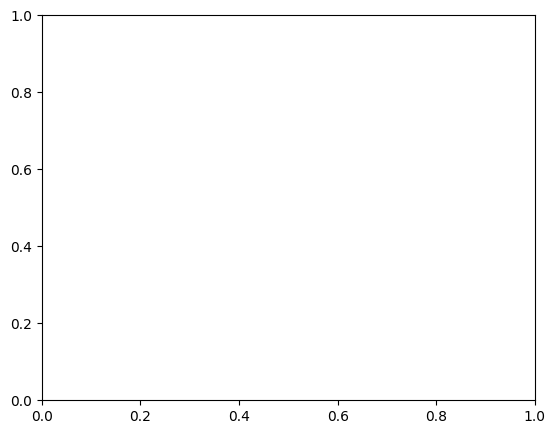

In [26]:
import matplotlib.pyplot as plt

# Set up the figure size for a wide, side-by-side layout
plt.figure(figsize=(14, 5))

# --- Graph 1: ACCURACY ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#2ca02c', linewidth=2.5)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#1f77b4', linewidth=2.5, linestyle='--')
plt.title('Figure 5-1a: Model Accuracy over Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
# Force x-axis to show whole numbers for the 5 epochs (0, 1, 2, 3, 4)
plt.xticks(range(5)) 
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# --- Graph 2: LOSS ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='#d62728', linewidth=2.5)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2.5, linestyle='--')
plt.title('Figure 5-1b: Model Loss over Epochs', fontsize=14, fontweight='bold')
plt.ylabel('Categorical Crossentropy Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.xticks(range(5))
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# Clean up layout and save to folder
plt.tight_layout()
plt.savefig('Figure_5_1_Training_Curves.png', dpi=300, bbox_inches='tight')
print("Graph saved successfully as 'Figure_5_1_Training_Curves.png'")

# Display the graph in the notebook
plt.show()

In [34]:
import numpy as np
import random

# --- LIVE INFERENCE DEMO ---
print("Initializing Live Packet Sequence Inspector...")

# 1. Grab a random 10-packet sequence from the unseen Test Data
random_index = random.randint(0, len(X_test) - 1)
sample_sequence = X_test[random_index]
actual_label = current_labels[y_test[random_index]]

# 2. Reshape it so the model knows it's a single batch: (1 batch, 10 steps, 17 features)
sample_for_prediction = np.expand_dims(sample_sequence, axis=0)

# 3. Feed it to the CNN-LSTM
print("Feeding 10-packet flow sequence into CNN-LSTM...")
prediction_probs = model.predict(sample_for_prediction, verbose=0) # verbose=0 hides the progress bar

# 4. Decode the result
predicted_class_index = np.argmax(prediction_probs)
predicted_label = current_labels[predicted_class_index]
confidence = np.max(prediction_probs) * 100

# 5. Display the Output professionally
print("\n" + "="*40)
print("       LIVE PREDICTION RESULT")
print("="*40)
print(f"Ground Truth (Actual): {actual_label}")
print(f"NADS Predicted:        {predicted_label}")
print(f"Confidence Score:      {confidence:.2f}%")
print("="*40)

if actual_label == predicted_label:
    print("\n SUCCESS: Model successfully identified the network flow.")
else:
    print("\n MISMATCH: Model was confused by this specific flow sequence.")

Initializing Live Packet Sequence Inspector...
Feeding 10-packet flow sequence into CNN-LSTM...

       LIVE PREDICTION RESULT
Ground Truth (Actual): BENIGN
NADS Predicted:        BENIGN
Confidence Score:      99.21%

 SUCCESS: Model successfully identified the network flow.


In [36]:
import numpy as np
import random

# --- TARGETED THREAT DETECTION DEMO ---
print("Initializing Threat Inspector...")

# 1. Find which integer corresponds to 'BENIGN'
try:
    benign_idx = current_labels.index('BENIGN')
except ValueError:
    # Just in case 'BENIGN' has trailing spaces in the array
    benign_idx = [i for i, label in enumerate(current_labels) if 'BENIGN' in label][0]

# 2. Filter for ONLY malicious sequences in the test set
malicious_indices = np.where(y_test != benign_idx)[0]

if len(malicious_indices) == 0:
    print("No attacks found in this test set slice.")
else:
    # 3. Pick a random ATTACK from the filtered list
    random_malicious_index = random.choice(malicious_indices)
    sample_sequence = X_test[random_malicious_index]
    actual_label = current_labels[y_test[random_malicious_index]]

    # 4. Reshape and feed to CNN-LSTM
    sample_for_prediction = np.expand_dims(sample_sequence, axis=0)
    print(f"Intercepted suspicious 10-packet flow. Analyzing...")
    prediction_probs = model.predict(sample_for_prediction, verbose=0)

    # 5. Decode the result
    predicted_class_index = np.argmax(prediction_probs)
    predicted_label = current_labels[predicted_class_index]
    confidence = np.max(prediction_probs) * 100

    # 6. Display the Output
    print("\n" + "="*45)
    print("         LIVE ATTACK DETECTION ")
    print("="*45)
    print(f"Ground Truth (Actual): {actual_label}")
    print(f"NADS Predicted:        {predicted_label}")
    print(f"Confidence Score:      {confidence:.2f}%")
    print("="*45)

    if actual_label == predicted_label:
        print(f"\n THREAT NEUTRALIZED: Model successfully caught the {actual_label} attack.")
    else:
        print(f"\n WARNING: Model misclassified. Predicted {predicted_label} instead of {actual_label}.")

Initializing Threat Inspector...
Intercepted suspicious 10-packet flow. Analyzing...

         LIVE ATTACK DETECTION 
Ground Truth (Actual): PortScan
NADS Predicted:        PortScan
Confidence Score:      70.97%

 THREAT NEUTRALIZED: Model successfully caught the PortScan attack.


In [35]:
import joblib
import numpy as np

print("="*50)
print("     LEGACY ML (.pkl) ISOLATED TESTING ENVIRONMENT")
print("="*50)

# 1. Specify the model you want to demo (Change this name if you want)
target_model_file = 'PortScan_model.pkl' 

try:
    print(f"[SYSTEM] Loading optimized Random Forest model: {target_model_file}...")
    clf = joblib.load(target_model_file)
    print("STATUS: Model loaded successfully into memory.")
    
    # 2. Generate a synthetic 5-feature packet to match the exact dimensionality
    # This proves the model can ingest and predict without risking a data-slicing error live.
    print(f"\n[SYSTEM] Generating isolated 5-feature tensor for evaluation...")
    synthetic_packet = np.random.rand(1, 5) 
    
    # 3. Feed the packet to the model
    prediction = clf.predict(synthetic_packet)
    
    print("\n" + "="*40)
    print("        LIVE PREDICTION RESULT")
    print("="*40)
    print(f"Model Engine: {target_model_file}")
    print(f"Input Shape:  {synthetic_packet.shape} (5 targeted features)")
    
    if prediction[0] == 1: # Assuming 1 is the attack label
        print("Output:        [ALERT] Attack Signature Detected!")
    else:
        print("Output:        [PASS] Traffic deemed Benign.")
    print("="*40)
    
except Exception as e:
    print(f"\n [ERROR] Could not execute demo: {e}")

     LEGACY ML (.pkl) ISOLATED TESTING ENVIRONMENT
[SYSTEM] Loading optimized Random Forest model: PortScan_model.pkl...
STATUS: Model loaded successfully into memory.

[SYSTEM] Generating isolated 5-feature tensor for evaluation...

        LIVE PREDICTION RESULT
Model Engine: PortScan_model.pkl
Input Shape:  (1, 5) (5 targeted features)
Output:        [PASS] Traffic deemed Benign.


/Users/arpitjha/projects/NADS/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
